<a href="https://colab.research.google.com/github/AbiFani/Challenge_TelecomX_parte2/blob/main/IA_aumentada_prevision_de_atrasos_de_vuelos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Optimizacion Aeroportuaria

In [ ]:
# importar biblioteca pandas
import pandas as pd

# leer archivo csv
datos = pd.read_csv('/content/flights.csv')




In [ ]:
# imprimir dataframe filas y columnas
datos.shape

(71175, 11)

In [ ]:
# conocer primeras 5 filas y columnas
datos.head()


,flight_id,airline,aircraft_type,schengen,origin,arrival_time,departure_time,day,year,is_holiday,delay
0,26,MM,Airbus A320,non-schengen,TCY,8.885071,10.885071,0,2010,False,70.205981
1,10,YE,Airbus A320,non-schengen,TCY,8.939996,11.939996,0,2010,False,38.484609
2,3,BZ,Embraer E175,schengen,TZF,18.635384,22.635384,0,2010,False,2.388305
3,28,BZ,Airbus A330,non-schengen,EMM,15.967963,17.967963,0,2010,False,19.138491
4,15,BZ,Airbus A330,non-schengen,FJB,16.571894,19.571894,0,2010,False,15.016271


In [ ]:
# conocer los metadatos
datos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 71175 entries, 0 to 71174
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   flight_id       71175 non-null  int64  
 1   airline         71175 non-null  object 
 2   aircraft_type   71175 non-null  object 
 3   schengen        71175 non-null  object 
 4   origin          71175 non-null  object 
 5   arrival_time    71175 non-null  float64
 6   departure_time  71175 non-null  float64
 7   day             71175 non-null  int64  
 8   year            71175 non-null  int64  
 9   is_holiday      71175 non-null  bool   
 10  delay           71175 non-null  float64
dtypes: bool(1), float64(3), int64(3), object(4)
memory usage: 5.5+ MB


In [ ]:
# conocer descripcion
datos.describe()

,flight_id,arrival_time,departure_time,day,year,delay
count,71175.000000,71175.000000,71175.000000,71175.000000,71175.000000,71175.000000
mean,15.465135,13.283159,16.480222,182.000000,2016.000000,12.548378
std,8.649646,4.023380,4.143705,105.366769,3.741684,23.125349
min,1.000000,7.065594,10.065594,0.000000,2010.000000,-41.028033
25%,8.000000,8.939996,12.668655,91.000000,2013.000000,-4.412876
50%,15.000000,14.258911,16.376052,182.000000,2016.000000,9.740454
75%,23.000000,16.909690,20.041281,273.000000,2019.000000,27.650853
max,30.000000,19.341235,23.341235,364.000000,2022.000000,125.632352


In [ ]:
# conocer variables categoricas
datos.describe(include='O')

,airline,aircraft_type,schengen,origin
count,71175,71175,71175,71175
unique,3,6,2,10
top,BZ,Airbus A320,schengen,TZF
freq,47598,30778,42569,14162


In [ ]:
# analisis grafico, importar biblioteca seaborn
import seaborn as sns
import matplotlib.pyplot as plt


In [ ]:
# conocer el promedio de retraso
avg_delay = datos.groupby('airline')['delay'].mean().reset_index()
print(avg_delay)

  airline      delay
0      BZ   3.077595
1      MM  40.498007
2      YE  25.772248


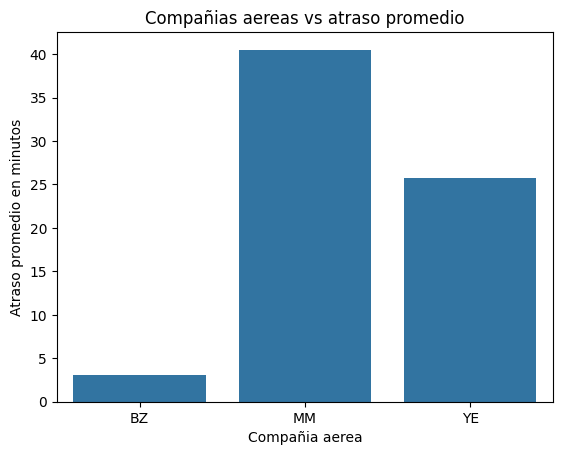

In [ ]:
# hacer el grafico
sns.barplot(x='airline', y='delay',data=avg_delay)
plt.title('Compañias aereas vs atraso promedio')
plt.xlabel('Compañia aerea')
plt.ylabel('Atraso promedio en minutos')
plt.show()

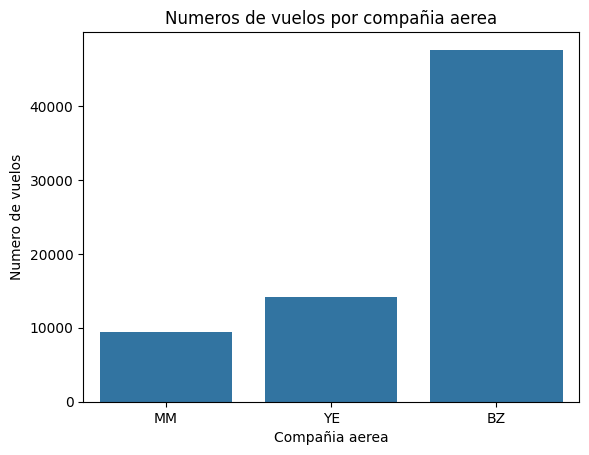

In [ ]:
# grafico de conteo
sns.countplot(x='airline', data=datos)
plt.title('Numeros de vuelos por compañia aerea')
plt.xlabel('Compañia aerea')
plt.ylabel('Numero de vuelos')
plt.show()

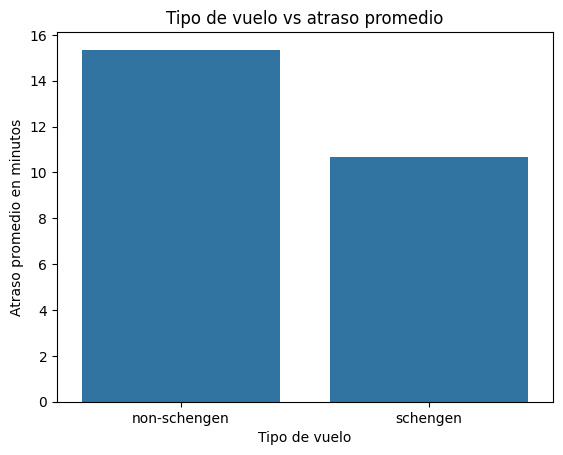

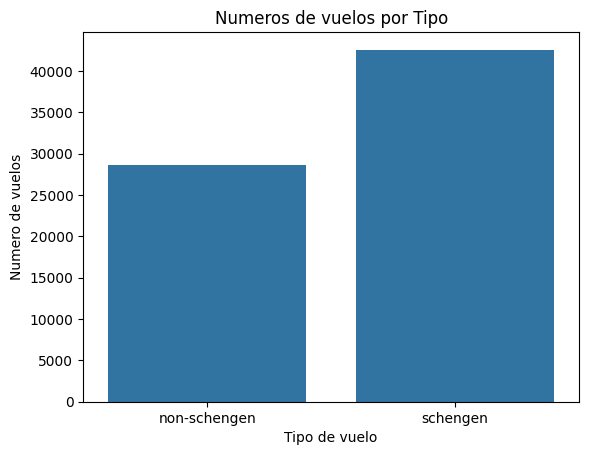

In [ ]:
# conocer el promedio de retraso
avg_delay = datos.groupby('schengen')['delay'].mean().reset_index()

# hacer el grafico de barras
sns.barplot(x='schengen', y='delay',data=avg_delay)
plt.title('Tipo de vuelo vs atraso promedio')
plt.xlabel('Tipo de vuelo')
plt.ylabel('Atraso promedio en minutos')
plt.show()

# grafico de conteo de vuelos
sns.countplot(x='schengen', data=datos)
plt.title('Numeros de vuelos por Tipo')
plt.xlabel('Tipo de vuelo')
plt.ylabel('Numero de vuelos')
plt.show()

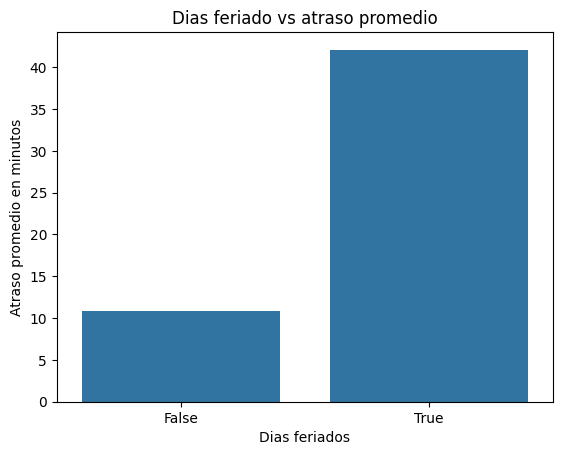

In [ ]:
# analis en dias feriados
# conocer el promedio de retraso
avg_delay = datos.groupby('is_holiday')['delay'].mean().reset_index()

# hacer el grafico de barras
sns.barplot(x='is_holiday', y='delay',data=avg_delay)
plt.title('Dias feriado vs atraso promedio')
plt.xlabel('Dias feriados')
plt.ylabel('Atraso promedio en minutos')
plt.show()


In [ ]:
#
datos['aircraft_type'].value_counts()

,count
aircraft_type,
Airbus A320,30778
Airbus A330,16654
Boeing 787,9606
Embraer E175,7098
Boeing 737,4722
Boeing 777,2317


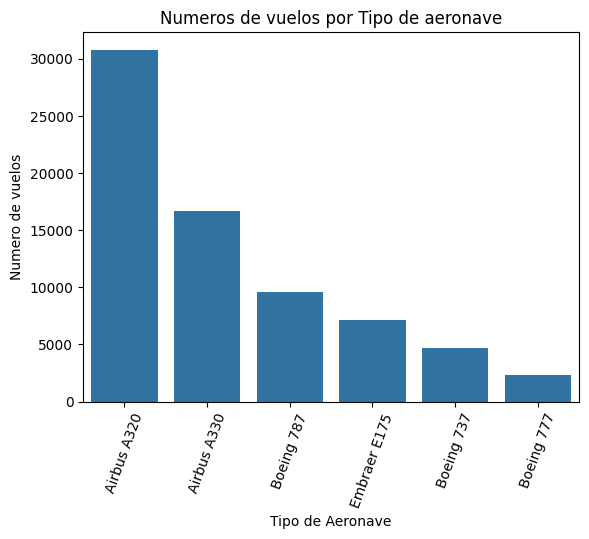

In [ ]:
# valores de las aeronaves
order = datos['aircraft_type'].value_counts().index

# grafico de conteo de vuelos
sns.countplot(x='aircraft_type', data=datos, order=order)
plt.title('Numeros de vuelos por Tipo de aeronave')
plt.xticks(rotation=70)
plt.xlabel('Tipo de Aeronave')
plt.ylabel('Numero de vuelos')
plt.show()

<Axes: xlabel='arrival_time', ylabel='Count'>

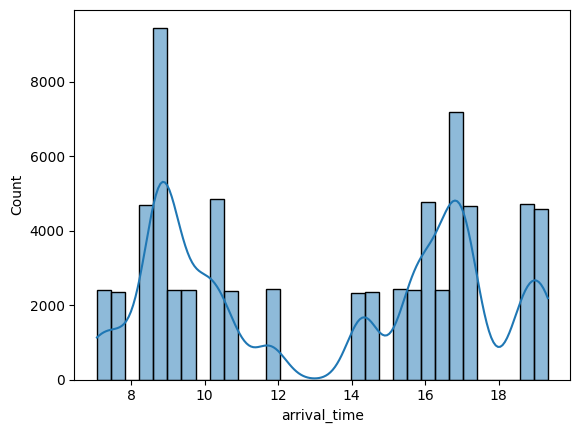

In [ ]:
# crear histograma
sns.histplot(data=datos, x='arrival_time', kde=True)

Regla de Freedman-Diaconis
https://en.wikipedia.org/wiki/Freedman%E2%80%93Diaconis_rule

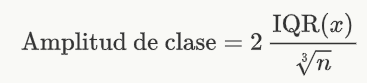

In [ ]:
# importar biblioteca numpy
import numpy as np


In [ ]:
# funcion intercuantil para crear formula
def ancho_bin(df,columna):
  q75,q25 = np.percentile(df[columna],[75,25])
  iqr = q75-q25
  ancho = 2 * iqr * np.power(len(df[columna]), -1/3)
  return ancho

<Axes: xlabel='arrival_time', ylabel='Count'>

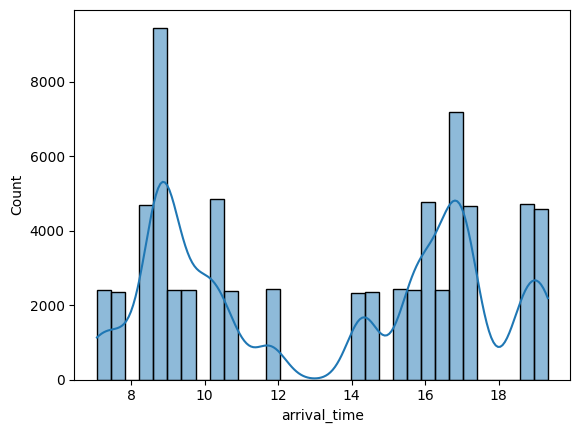

In [ ]:
# crear variable binwidth
binwidth = ancho_bin(datos,'arrival_time')

# crear grafico de hora de llagada
sns.histplot(data=datos,x='arrival_time',kde=True,binwidth=binwidth)

<Axes: xlabel='arrival_time', ylabel='Count'>

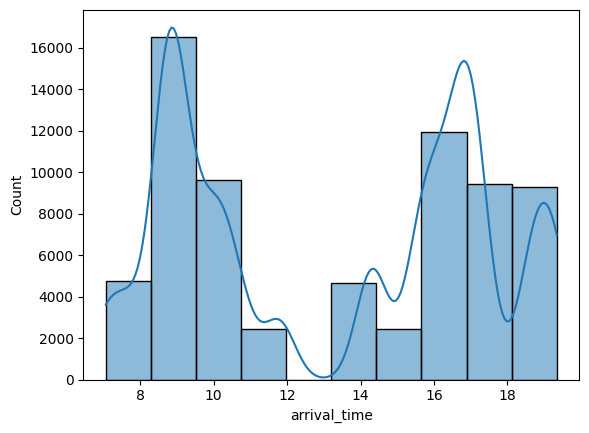

In [ ]:
# grafico manualmente
sns.histplot(data=datos,x='arrival_time',kde=True,bins=10)

<Axes: xlabel='departure_time', ylabel='Count'>

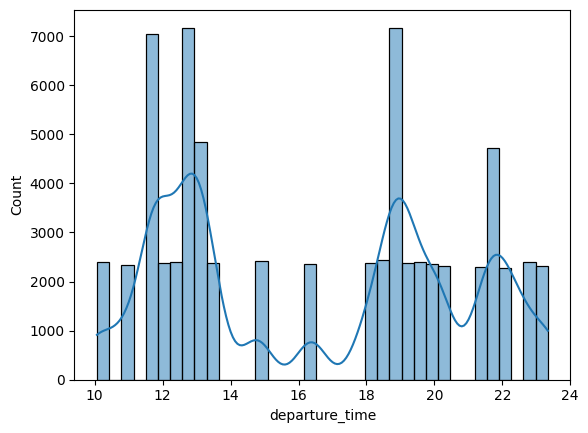

In [ ]:
# grafico de hora de salida
binwidth = ancho_bin(datos,'departure_time')
sns.histplot(data=datos,x='departure_time',kde=True,binwidth=binwidth)

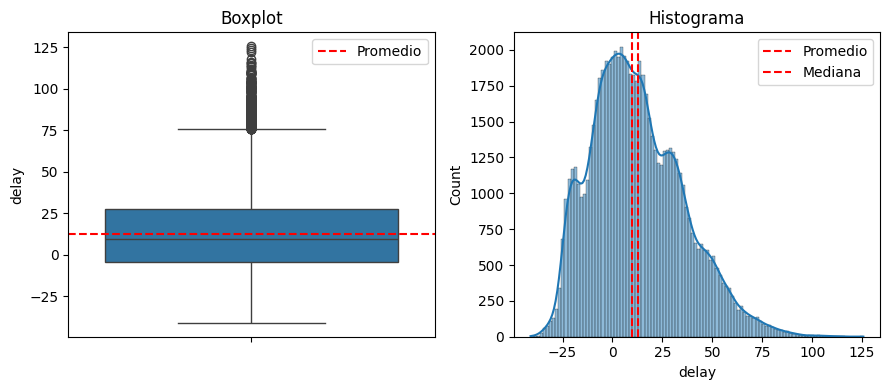

In [ ]:
# importar biblioteca
from matplotlib import legend

# grafico de retraso de vuelo
atraso_promedio = datos['delay'].mean()
atraso_mediana = datos['delay'].median()

# dibujar lienzo
fig, ax = plt.subplots(1,2,figsize=(9,4))

# grafico de boxplot-caja del promedio
sns.boxplot(data=datos, y='delay', ax=ax[0])
ax[0].set_title('Boxplot')
ax[0].axhline(y=atraso_promedio, color='r', linestyle='--',label='Promedio')
ax[0].legend()

# grafico histograma de mediana
binwidth=ancho_bin(datos,'delay')
sns.histplot(data=datos,x='delay',ax=ax[1],kde=True,binwidth=binwidth)
plt.grid(False)
ax[1].set_title('Histograma')
ax[1].axvline(x=atraso_promedio, color='r', linestyle='--',label='Promedio')
ax[1].axvline(x=atraso_mediana, color='r', linestyle='--',label='Mediana')
ax[1].legend()

plt.tight_layout()

plt.show()

# CLASE 2


In [ ]:
# mostrar columnas del df datos
datos.columns


Index(['flight_id', 'airline', 'aircraft_type', 'schengen', 'origin',
       'arrival_time', 'departure_time', 'day', 'year', 'is_holiday', 'delay'],
      dtype='object')

In [ ]:
# crear columna date
datos['date'] = datos['year'].astype(str) + '-' + (datos['day']+1).astype(str)

# mostrar df datos
datos.head()

,flight_id,airline,aircraft_type,schengen,origin,arrival_time,departure_time,day,year,is_holiday,delay,date
0,26,MM,Airbus A320,non-schengen,TCY,8.885071,10.885071,0,2010,False,70.205981,2010-1
1,10,YE,Airbus A320,non-schengen,TCY,8.939996,11.939996,0,2010,False,38.484609,2010-1
2,3,BZ,Embraer E175,schengen,TZF,18.635384,22.635384,0,2010,False,2.388305,2010-1
3,28,BZ,Airbus A330,non-schengen,EMM,15.967963,17.967963,0,2010,False,19.138491,2010-1
4,15,BZ,Airbus A330,non-schengen,FJB,16.571894,19.571894,0,2010,False,15.016271,2010-1


In [ ]:
# modificar fecha date
datos['date'] = pd.to_datetime(datos['date'],format='%Y-%j')
datos.tail(2)

,flight_id,airline,aircraft_type,schengen,origin,arrival_time,departure_time,day,year,is_holiday,delay,date
71173,5,BZ,Airbus A320,schengen,ZQO,9.344097,12.344097,364,2022,True,56.758844,2022-12-31
71174,29,BZ,Boeing 737,schengen,ZQO,8.591208,11.591208,364,2022,True,41.401648,2022-12-31


In [ ]:
# crear columna fin de semana
datos['is_weekend'] = datos['date'].dt.weekday.isin([5,6])
# mostrar dia de la semana
datos['day_name'] = datos['date'].dt.day_name()
# mostrar una muestra de 5 filas
datos.sample(5)

,flight_id,airline,aircraft_type,schengen,origin,arrival_time,departure_time,day,year,is_holiday,delay,date,is_weekend,day_name
65392,17,BZ,Airbus A330,non-schengen,CNU,16.718722,21.718722,344,2021,False,-9.517267,2021-12-11,True,Saturday
16607,26,MM,Airbus A320,non-schengen,TCY,8.885071,10.885071,12,2013,False,26.393399,2013-01-13,True,Sunday
19636,17,BZ,Airbus A330,non-schengen,CNU,16.718722,21.718722,214,2013,False,-6.493642,2013-08-03,True,Saturday
11388,20,YE,Boeing 787,schengen,MWL,16.909690,18.909690,29,2012,False,56.771173,2012-01-30,False,Monday
64419,29,BZ,Boeing 737,schengen,ZQO,8.591208,11.591208,279,2021,False,13.138051,2021-10-07,False,Thursday


In [ ]:
# mostrar tipo de datos
datos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 71175 entries, 0 to 71174
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   flight_id       71175 non-null  int64         
 1   airline         71175 non-null  object        
 2   aircraft_type   71175 non-null  object        
 3   schengen        71175 non-null  object        
 4   origin          71175 non-null  object        
 5   arrival_time    71175 non-null  float64       
 6   departure_time  71175 non-null  float64       
 7   day             71175 non-null  int64         
 8   year            71175 non-null  int64         
 9   is_holiday      71175 non-null  bool          
 10  delay           71175 non-null  float64       
 11  date            71175 non-null  datetime64[ns]
 12  is_weekend      71175 non-null  bool          
 13  day_name        71175 non-null  object        
dtypes: bool(2), datetime64[ns](1), float64(3), int64(3), o

In [ ]:
# cancelar advertencias sobre las modificaciones
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# modificar tipo de datos con dos categorias
datos['schengen'] = datos['schengen'].replace({'non-schengen':0,'schengen':1})
datos['is_holiday'] = datos['is_holiday'].replace({False:0,True:1})
datos['is_weekend'] = datos['is_weekend'].replace({False:0,True:1})
# mostrar 3 muestras
datos

,flight_id,airline,aircraft_type,schengen,origin,arrival_time,departure_time,day,year,is_holiday,delay,date,is_weekend,day_name
0,26,MM,Airbus A320,0,TCY,8.885071,10.885071,0,2010,0,70.205981,2010-01-01,0,Friday
1,10,YE,Airbus A320,0,TCY,8.939996,11.939996,0,2010,0,38.484609,2010-01-01,0,Friday
2,3,BZ,Embraer E175,1,TZF,18.635384,22.635384,0,2010,0,2.388305,2010-01-01,0,Friday
3,28,BZ,Airbus A330,0,EMM,15.967963,17.967963,0,2010,0,19.138491,2010-01-01,0,Friday
4,15,BZ,Airbus A330,0,FJB,16.571894,19.571894,0,2010,0,15.016271,2010-01-01,0,Friday
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
71170,3,BZ,Embraer E175,1,TZF,18.635384,22.635384,364,2022,1,25.677277,2022-12-31,1,Saturday
71171,17,BZ,Airbus A330,0,CNU,16.718722,21.718722,364,2022,1,52.624348,2022-12-31,1,Saturday
71172,7,MM,Boeing 787,1,TZF,8.564949,13.564949,364,2022,1,56.167080,2022-12-31,1,Saturday
71173,5,BZ,Airbus A320,1,ZQO,9.344097,12.344097,364,2022,1,56.758844,2022-12-31,1,Saturday


In [ ]:
# crear variables categoricas
categoricas = ['airline','aircraft_type','origin','day_name']

# codificar variables con 0, 1
pd.get_dummies(data= datos,columns=categoricas,dtype=int).head()

,flight_id,schengen,arrival_time,departure_time,day,year,is_holiday,delay,date,is_weekend,...,origin_TCY,origin_TZF,origin_ZQO,day_name_Friday,day_name_Monday,day_name_Saturday,day_name_Sunday,day_name_Thursday,day_name_Tuesday,day_name_Wednesday
0,26,0,8.885071,10.885071,0,2010,0,70.205981,2010-01-01,0,...,1,0,0,1,0,0,0,0,0,0
1,10,0,8.939996,11.939996,0,2010,0,38.484609,2010-01-01,0,...,1,0,0,1,0,0,0,0,0,0
2,3,1,18.635384,22.635384,0,2010,0,2.388305,2010-01-01,0,...,0,1,0,1,0,0,0,0,0,0
3,28,0,15.967963,17.967963,0,2010,0,19.138491,2010-01-01,0,...,0,0,0,1,0,0,0,0,0,0
4,15,0,16.571894,19.571894,0,2010,0,15.016271,2010-01-01,0,...,0,0,0,1,0,0,0,0,0,0


In [ ]:
# crear variable datos codificados y almacenar dummies
datos_codificados = pd.get_dummies(data= datos,columns=categoricas,dtype=int)

# mostrar 5 muestras
datos_codificados.sample(5)


,flight_id,schengen,arrival_time,departure_time,day,year,is_holiday,delay,date,is_weekend,...,origin_TCY,origin_TZF,origin_ZQO,day_name_Friday,day_name_Monday,day_name_Saturday,day_name_Sunday,day_name_Thursday,day_name_Tuesday,day_name_Wednesday
31167,10,0,8.939996,11.939996,252,2015,0,61.964079,2015-09-10,0,...,1,0,0,0,0,0,0,1,0,0
1621,6,1,17.033688,19.033688,108,2010,0,3.212003,2010-04-19,0,...,0,0,0,0,1,0,0,0,0,0
12494,23,1,18.801235,21.801235,102,2012,0,18.989775,2012-04-12,0,...,1,0,0,0,0,0,0,1,0,0
64271,8,1,15.729617,18.729617,269,2021,0,-6.186813,2021-09-27,0,...,0,0,1,0,1,0,0,0,0,0
14092,21,1,7.065594,10.065594,209,2012,0,52.773381,2012-07-28,1,...,0,0,0,0,0,1,0,0,0,0


In [ ]:
# mostrar correlacion
datos[['arrival_time','departure_time']].corr()

,arrival_time,departure_time
arrival_time,1.000000,0.973797
departure_time,0.973797,1.000000


In [ ]:
# motrar datos codificados tipo de datos
datos_codificados.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 71175 entries, 0 to 71174
Data columns (total 36 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   flight_id                   71175 non-null  int64         
 1   schengen                    71175 non-null  int64         
 2   arrival_time                71175 non-null  float64       
 3   departure_time              71175 non-null  float64       
 4   day                         71175 non-null  int64         
 5   year                        71175 non-null  int64         
 6   is_holiday                  71175 non-null  int64         
 7   delay                       71175 non-null  float64       
 8   date                        71175 non-null  datetime64[ns]
 9   is_weekend                  71175 non-null  int64         
 10  airline_BZ                  71175 non-null  int64         
 11  airline_MM                  71175 non-null  int64     

In [ ]:
# eliminar columnas date, year, identificacion
df = datos_codificados.drop(columns=['flight_id','departure_time','day','year','date'])
# mostrar 10 muestras
df.sample(10)

,schengen,arrival_time,is_holiday,delay,is_weekend,airline_BZ,airline_MM,airline_YE,aircraft_type_Airbus A320,aircraft_type_Airbus A330,...,origin_TCY,origin_TZF,origin_ZQO,day_name_Friday,day_name_Monday,day_name_Saturday,day_name_Sunday,day_name_Thursday,day_name_Tuesday,day_name_Wednesday
6112,1,7.065594,0,35.370296,1,1,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
19505,1,8.591208,0,9.132086,0,1,0,0,0,0,...,0,0,1,0,0,0,0,1,0,0
51704,1,16.245220,0,52.770235,0,0,1,0,1,0,...,0,1,0,0,0,0,0,0,1,0
39667,1,8.591208,0,3.501971,0,1,0,0,0,0,...,0,0,1,1,0,0,0,0,0,0
22872,0,15.496519,0,9.591576,0,1,0,0,1,0,...,0,0,0,0,0,0,0,1,0,0
60986,0,15.496519,0,24.885158,1,1,0,0,1,0,...,0,0,0,0,0,1,0,0,0,0
44858,1,18.801235,0,36.730284,0,0,0,1,0,0,...,1,0,0,0,1,0,0,0,0,0
31662,1,18.635384,0,-19.422901,0,1,0,0,0,0,...,0,1,0,0,0,0,0,0,1,0
16447,0,10.172731,0,-17.295478,0,1,0,0,0,0,...,1,0,0,0,0,0,0,0,0,1
37000,0,19.341235,0,8.152519,0,1,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0


# Clase 3

https://scikit-learn.org/stable/modules/clustering.html


In [ ]:
# importar biblioteca
from sklearn.dummy import DummyRegressor
from sklearn.model_selection import train_test_split

In [ ]:
# crear variables independientes
X = df.drop(['delay'],axis=1)
# variable de respuesta
y = df['delay']

# crear modelo
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.3,random_state=42)

# crear modelo baseline
baseline = DummyRegressor()
# entrenat modelo
baseline.fit(X_train,y_train)

DummyRegressor()

In [ ]:
# evaluar modelo usando metricas
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np # Import numpy for sqrt

# crear variable
y_pred_dummy = baseline.predict(X_test)

# crear funcion
def calcular_regresion(y_test,y_pred):
    rmse = mean_squared_error(y_test,y_pred)
    mae = mean_absolute_error(y_test,y_pred)
    r2 = r2_score(y_test,y_pred)
    metricas = {
        'RMSE':round(rmse**(1/2),4),
        'MAE':round(mae,4),
        'R2':round(r2,4)
    }
    return metricas

In [ ]:
# imprimir resultados
resultados_baseline = calcular_regresion(y_test,y_pred_dummy)
resultados_baseline

{'RMSE': 23.1612, 'MAE': 18.5646, 'R2': -0.0}

# Bosques aleatorios

In [ ]:
# importar biblioteca
from sklearn.ensemble import RandomForestRegressor

# crear modelo
modelo = RandomForestRegressor(max_depth=100,random_state=42)

# entrenar modelo
modelo.fit(X_train,y_train)
y_pred = modelo.predict(X_test)
resultados_rf = calcular_regresion(y_test,y_pred)
resultados_rf


{'RMSE': 13.2724, 'MAE': 10.6366, 'R2': 0.6716}

## Prediction Error Plot - Quick Method
https://www.scikit-yb.org/en/latest/api/regressor/peplot.html?highlight=prediction+error+plot

La misma funcionalidad se puede lograr con el método rápido asociado prediction_error. Este método construirá el PredictionErrorobjeto con los argumentos asociados, lo ajustará y luego (opcionalmente) mostrará inmediatamente la visualización.

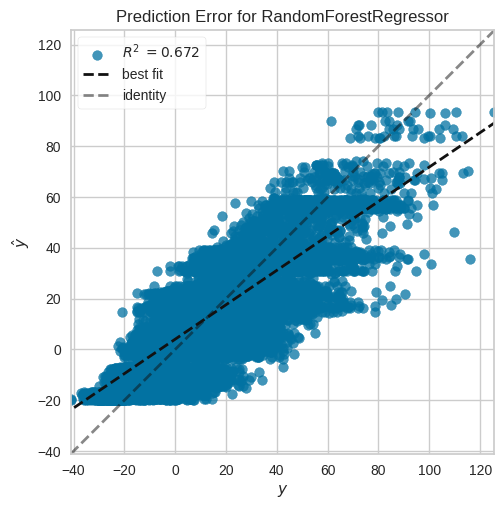

In [ ]:
# prediccion del error
from yellowbrick.regressor import prediction_error

# crear visualizacion del modelo
visualizer = prediction_error(modelo, X_train, y_train, X_test, y_test)

## Residuals Plot - Quick Method

Se puede lograr una funcionalidad similar a la anterior en una sola línea utilizando el método rápido asociado residuals_plot. Este método instanciará y ajustará un ResidualsPlotvisualizador a los datos de entrenamiento, y luego lo calificará con los datos de prueba opcionales (o con los datos de entrenamiento si no se proporcionan).

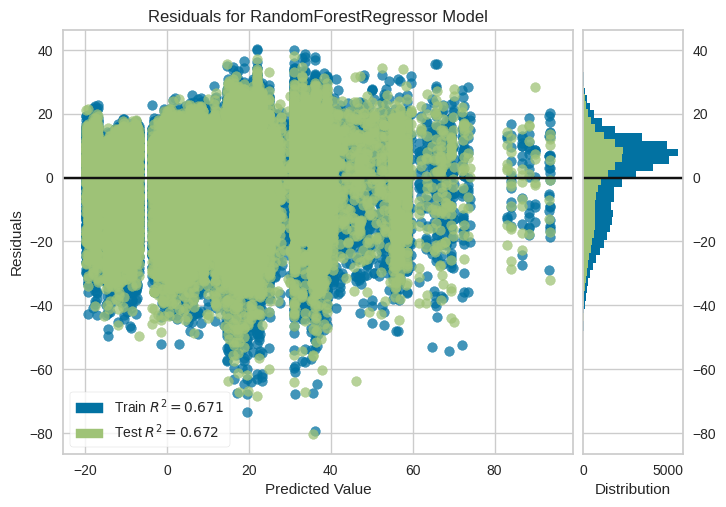

In [ ]:
# grafico de residuos
from yellowbrick.regressor import residuals_plot

# Create the visualizer, fit, score, and show it
viz = residuals_plot(modelo, X_train, y_train, X_test, y_test);

## KFOLD
https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.KFold.html

## cross_validate
https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.cross_validate.html#sklearn.model_selection.cross_validate

## String name scorers
https://scikit-learn.org/stable/modules/model_evaluation.html#string-name-scorers

Por lo tanto, las métricas que miden la distancia entre el modelo y los datos, como metrics.mean_squared_error, están disponibles como 'neg_mean_squared_error', que devuelve el valor negado de la métrica.



In [ ]:
# importar biblioteca
from sklearn.model_selection import KFold, cross_validate

# Diccionario de validacion cruzada
scoring = {
    'RMSE':'neg_root_mean_squared_error', #
    'MAE':'neg_mean_absolute_error', # error promedio absoluto
    'R2':'r2' # coeficiente de determinacion
}


# crear variable
cv = KFold (n_splits = 5, shuffle = True,random_state = 42)
cv_results = cross_validate(modelo, X_train, y_train, scoring=scoring, cv=cv)
# visualizar resultado
cv_results

{'fit_time': array([7.45410228, 5.48564386, 4.57209063, 5.20339727, 4.28467774]),
 'score_time': array([0.25285721, 0.10283899, 0.14129591, 0.10606599, 0.10587263]),
 'test_RMSE': array([-13.25158032, -13.34915539, -13.49167318, -13.35212302,
        -13.4774009 ]),
 'test_MAE': array([-10.63438301, -10.73569604, -10.83255123, -10.71557526,
        -10.81439961]),
 'test_R2': array([0.67177308, 0.66413908, 0.65969548, 0.66641454, 0.66068985])}

# Clase 4

In [ ]:
# ver columnas del df
df.columns


Index(['schengen', 'arrival_time', 'is_holiday', 'delay', 'is_weekend',
       'airline_BZ', 'airline_MM', 'airline_YE', 'aircraft_type_Airbus A320',
       'aircraft_type_Airbus A330', 'aircraft_type_Boeing 737',
       'aircraft_type_Boeing 777', 'aircraft_type_Boeing 787',
       'aircraft_type_Embraer E175', 'origin_AUZ', 'origin_CNU', 'origin_CSF',
       'origin_EMM', 'origin_FJB', 'origin_MWL', 'origin_PUA', 'origin_TCY',
       'origin_TZF', 'origin_ZQO', 'day_name_Friday', 'day_name_Monday',
       'day_name_Saturday', 'day_name_Sunday', 'day_name_Thursday',
       'day_name_Tuesday', 'day_name_Wednesday'],
      dtype='object')

In [ ]:
# conocer atributos del df
len(df.columns)

31

In [ ]:
# consultar atributos importantes
modelo.feature_importances_


array([9.48264263e-03, 4.03840154e-02, 1.38333502e-01, 4.66128986e-04,
       5.02831915e-01, 1.19210296e-04, 1.37699490e-04, 9.63731166e-02,
       5.47009858e-02, 1.71921315e-03, 1.39639618e-04, 1.98062060e-02,
       4.36255527e-02, 1.29370043e-03, 7.00150786e-04, 1.44472801e-02,
       3.49895326e-03, 1.55295028e-02, 4.97084264e-04, 9.55149731e-03,
       2.55352392e-02, 6.34102505e-03, 5.13831155e-03, 2.99200337e-03,
       1.08985490e-03, 8.68768836e-04, 9.13518354e-04, 8.85913232e-04,
       1.19193336e-03, 1.40543476e-03])

In [ ]:
# guardar en un df
importances = modelo.feature_importances_

In [ ]:
# crear diccionario
feature_importances = pd.DataFrame ({
    'Feature':X.columns,
    'importances':(importances*100).round(2)
}).sort_values('importances',ascending=False)

# mostrar diccionario
feature_importances

,Feature,importances
4,airline_BZ,50.28
2,is_holiday,13.83
7,aircraft_type_Airbus A320,9.64
8,aircraft_type_Airbus A330,5.47
12,aircraft_type_Embraer E175,4.36
1,arrival_time,4.04
20,origin_TCY,2.55
11,aircraft_type_Boeing 787,1.98
17,origin_FJB,1.55
15,origin_CSF,1.44


In [ ]:
# lista de features
[i if i !=0 else 1 for i in range(0,35,5)]

[1, 5, 10, 15, 20, 25, 30]

In [ ]:
# crear df con indices de metricas
resultados = pd.DataFrame(index=['RMSE','MAE','R2'])

# crear modelo
modelo_features = RandomForestRegressor(max_depth=5,random_state=42)

# crear lista de iteracion de las metricas
ct_features = [i if i !=0 else 1 for i in range(0,35,5)]

# iterar features
for i in ct_features:
  # crear variables, seleccionando 'i' caracteristicas principales
  selected_features = feature_importances['Feature'].values[:i]
  X_train_sel = X_train[selected_features]
  X_test_sel = X_test[selected_features]
  # entrenar modelo
  modelo_features.fit(X_train_sel,y_train)
  y_pred = modelo_features.predict(X_test_sel)
  # calcular metricas para el conjunto de caracteristicas actual
  metricas = calcular_regresion(y_test,y_pred)
  # guardar resultados
  resultados[i] = list(metricas.values())

# mostrar resultados del df
resultados

,1,5,10,15,20,25,30
RMSE,18.8331,15.1564,13.7584,13.7560,13.7490,13.7481,13.7479
MAE,14.9620,12.0605,11.0419,11.0419,11.0274,11.0262,11.0262
R2,0.3388,0.5718,0.6471,0.6472,0.6476,0.6477,0.6477


In [ ]:
# crear df con indices de metricas
resultados = pd.DataFrame(index=['RMSE','MAE','R2'])

# crear modelo
modelo_features = RandomForestRegressor(max_depth=5,random_state=42)

# crear lista de iteracion de las metricas, cambiar cantidad de features
ct_features = range(10,16)

# iterar features
for i in ct_features:
  # crear variables, seleccionando 'i' caracteristicas principales
  selected_features = feature_importances['Feature'].values[:i]
  X_train_sel = X_train[selected_features]
  X_test_sel = X_test[selected_features]
  # entrenar modelo
  modelo_features.fit(X_train_sel,y_train)
  y_pred = modelo_features.predict(X_test_sel)
  # calcular metricas para el conjunto de caracteristicas actual
  metricas = calcular_regresion(y_test,y_pred)
  # guardar resultados
  resultados[i] = list(metricas.values())

# mostrar resultados
resultados

,10,11,12,13,14,15
RMSE,13.7584,13.7584,13.7582,13.7560,13.7560,13.7560
MAE,11.0419,11.0419,11.0415,11.0419,11.0419,11.0419
R2,0.6471,0.6471,0.6471,0.6472,0.6472,0.6472


In [ ]:
# seleccionar 13 features
selected_features = feature_importances['Feature'].values[:13]
X_selected_features = X[selected_features]
# mostrar las features mas importantes
X_selected_features


,airline_BZ,is_holiday,aircraft_type_Airbus A320,aircraft_type_Airbus A330,aircraft_type_Embraer E175,arrival_time,origin_TCY,aircraft_type_Boeing 787,origin_FJB,origin_CSF,origin_PUA,schengen,origin_TZF
0,0,0,1,0,0,8.885071,1,0,0,0,0,0,0
1,0,0,1,0,0,8.939996,1,0,0,0,0,0,0
2,1,0,0,0,1,18.635384,0,0,0,0,0,1,1
3,1,0,0,1,0,15.967963,0,0,0,0,0,0,0
4,1,0,0,1,0,16.571894,0,0,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
71170,1,1,0,0,1,18.635384,0,0,0,0,0,1,1
71171,1,1,0,1,0,16.718722,0,0,0,0,0,0,0
71172,0,1,0,0,0,8.564949,0,1,0,0,0,1,1
71173,1,1,1,0,0,9.344097,0,0,0,0,0,1,0


In [ ]:
# hacer la division
X_train, X_test, y_train, y_test = train_test_split(X_selected_features,y,random_state=42)
#


##RandomForestRegressor - regresor de bosque aleatorio.

https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestRegressor.html

Los árboles del bosque utilizan la mejor estrategia de división, equivalente a pasar splitter="best"al subyacente DecisionTreeRegressor. El tamaño de la submuestra se controla con el max_samplesparámetro `if` bootstrap=True(predeterminado); de lo contrario, se utiliza todo el conjunto de datos para construir cada árbol.

##GridSearchCV
https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html#gridsearchcv

Búsqueda exhaustiva de valores de parámetros específicos para un estimador.
Los miembros importantes están en forma, pronostican.

In [ ]:
# ajustar hiperparametros, crear diccionario
param_grid = {
    'max_depth':[5,10,15],
    'min_samples_leaf':[1,2,3],
    'min_samples_split':[2,4,6],
    'n_estimators':[100,200,300]
}

In [ ]:
# importar GridSearchCv
from sklearn.model_selection import GridSearchCV

# crear variable
cv = KFold (n_splits = 6, shuffle=True, random_state=42)
# crear modelo
model_grid = GridSearchCV(RandomForestRegressor(random_state=42),
                          param_grid=param_grid, scoring='r2',
                          cv=cv)
# entrenar modelo
model_grid.fit(X_train,y_train)

GridSearchCV(cv=KFold(n_splits=6, random_state=42, shuffle=True),
             estimator=RandomForestRegressor(random_state=42),
             param_grid={'max_depth': [5, 10, 15],
                         'min_samples_leaf': [1, 2, 3],
                         'min_samples_split': [2, 4, 6],
                         'n_estimators': [100, 200, 300]},
             scoring='r2')

In [ ]:
# conocer los mejores estimadores
model_grid.best_params_

{'max_depth': 15,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'n_estimators': 100}

In [ ]:
# conocer prediccion
y_pred_grid = model_grid.predict(X_test)
# cooncer las metricas
metricas_model_grid = calcular_regresion(y_test,y_pred_grid)
metricas_model_grid


{'RMSE': 13.2552, 'MAE': 10.6675, 'R2': 0.6742}

In [ ]:
# crear nueva columna en df resultados
resultados['modelo_grid'] = list(metricas_model_grid.values())
resultados

,10,11,12,13,14,15,modelo_grid
RMSE,13.7584,13.7584,13.7582,13.7560,13.7560,13.7560,13.2552
MAE,11.0419,11.0419,11.0415,11.0419,11.0419,11.0419,10.6675
R2,0.6471,0.6471,0.6471,0.6472,0.6472,0.6472,0.6742


In [ ]:
# importar biblioteca pickle para serializado-guardado
import pickle

try: # en caso de error
# guardar modelo-serializar
  with open('champion.pkl','wb') as file:
    pickle.dump(model_grid.best_estimator_,file)
  print('Modelo serializado guardado con exito')
except Exception as e:
  print('Se presento un error al almacenar el modelo: ',str(e))
# fin

Modelo serializado guardado con exito


---
---

## crear una nueva muestra

Concluimos el proceso de desarrollo, optimización y guardado del modelo. Sin embargo, surge la cuestión de cómo utilizar efectivamente este modelo en situaciones prácticas. ¿Cómo podemos aprovechar el modelo que fue **guardado** para realizar predicciones actualizadas?

Ante esto, construye un código que **cargue el modelo guardado** y realice la predicción para la siguiente muestra:

In [ ]:
import pickle

In [ ]:
file_path = '/content/champion.pkl'

try:
    with open(file_path, 'rb') as file:
        model = pickle.load(file)
    print("¡Modelo cargado con éxito!")
except Exception as e:
    print("Ocurrió un error al cargar el modelo:", str(e))

¡Modelo cargado con éxito!


In [ ]:
# construye un código que cargue el modelo guardado y realice la predicción para la siguiente muestra:
nueva_muestra = [0.0, 10.8941, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0]

In [ ]:
# Ejemplo de predicción con datos de entrada 'X'
model.predict([nueva_muestra])[0]

np.float64(48.53788177833645)